# Model Evaluation and Performance Metrics

**Applied ML in Production · Session 5**

---

You can already compute accuracy, precision, recall, F1 and ROC-AUC. This session
is about a harder question: **which one do you report, and why that one?**

It matters more than it sounds. Every metric is a different opinion about which
mistakes are worse. Choose accuracy on this dataset and a model that declines
nobody looks excellent. Choose F1 and you will pick an operating point that costs
the lender millions more than a different one. The metric is not a technicality
at the end of the project — it is a business decision made in session 1 and
cashed in here.

So we start from the four numbers everything is built on, and finish by choosing
a threshold with money rather than with habit.

## How to work through this

Type the code. Most cells are a confusion matrix or a loop over thresholds, and
the arithmetic is deliberately visible so you can check it by hand.

Run each cell, read the output, then read the commentary. If a cell errors, run
from the top.

## Learning objectives

After this session you will be able to:

- Read a confusion matrix in business language rather than statistical language.
- Derive accuracy, precision, recall, specificity and F1 from those four numbers.
- Explain why accuracy is the wrong headline metric for an imbalanced problem.
- Choose between ROC-AUC and precision–recall AUC, and justify the choice from
  the base rate.
- Build a **cost matrix** and pick the threshold that minimises expected cost.
- Reconcile the cheapest operating point with an operational **capacity** limit.
- Check whether predicted probabilities are **calibrated**, and say why that
  matters for money-based decisions.
- Pick the right regression metric for a regression problem.

## Setup

One model, trained once, used for the whole session: session 4's pipeline on
session 2's honest features. No `class_weight` this time — we will do the work
with the threshold instead, as session 3 showed.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 130)


def find_data(filename="loan_default.csv"):
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"could not find data/{filename}")


loans = pd.read_csv(find_data(), parse_dates=["application_date"])

features = loans[["loan_amount", "tenure_months", "interest_rate", "previous_loans",
                  "days_past_due_history", "annual_income", "credit_score",
                  "sector", "employment_type", "has_collateral"]].copy()
features["income_missing"] = features["annual_income"].isna().astype(int)
features["score_missing"] = features["credit_score"].isna().astype(int)

X = pd.get_dummies(features, drop_first=True).astype(float)
y = loans["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
medians = X_train.median()
X_train, X_test = X_train.fillna(medians), X_test.fillna(medians)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

probabilities = model.predict_proba(X_test)[:, 1]
loan_amounts = loans.loc[X_test.index, "loan_amount"].to_numpy()
actual = y_test.to_numpy()

print(f"{len(actual):,} test applications, {actual.mean():.1%} defaulted")

3,000 test applications, 13.5% defaulted


---

## 1. Four numbers, in business language

Every classification metric in existence is built from the same four counts. Fix a
threshold, compare predictions to reality, and you get:

| | Model says repay | Model says default |
|---|---|---|
| **Actually repaid** | True negative — approved, repaid. The business as usual | **False positive** — a *false alarm*. We declined or delayed a good customer |
| **Actually defaulted** | **False negative** — a *missed default*. Money out the door | True positive — caught it. The whole point of the project |

Learn the business names. "False negative" means nothing to a Head of Credit;
"we approved a loan that went bad" means everything.

In [2]:
from sklearn.metrics import confusion_matrix

THRESHOLD = 0.15
predictions = (probabilities >= THRESHOLD).astype(int)

true_negative, false_positive, false_negative, true_positive = \
    confusion_matrix(actual, predictions).ravel()

print(f"threshold {THRESHOLD}\n")
print(f"  caught defaults (true positive):   {true_positive:>5}")
print(f"  missed defaults (false negative):  {false_negative:>5}")
print(f"  false alarms    (false positive):  {false_positive:>5}")
print(f"  quiet approvals (true negative):   {true_negative:>5}")

threshold 0.15

  caught defaults (true positive):     261
  missed defaults (false negative):    144
  false alarms    (false positive):    659
  quiet approvals (true negative):    1936


### Every metric is a ratio of those four

| Metric | Formula | The question it answers |
|--------|---------|-------------------------|
| **Accuracy** | (TP + TN) / everything | How often are we right? |
| **Precision** | TP / (TP + FP) | When we flag a file, how often is it really bad? |
| **Recall** (sensitivity) | TP / (TP + FN) | Of all the bad loans, how many did we catch? |
| **Specificity** | TN / (TN + FP) | Of all the good loans, how many did we leave alone? |
| **F1** | harmonic mean of precision and recall | One number when you refuse to choose between them |

In [3]:
print(f"accuracy    {(true_positive + true_negative) / len(actual):.3f}")
print(f"precision   {true_positive / (true_positive + false_positive):.3f}")
print(f"recall      {true_positive / (true_positive + false_negative):.3f}")
print(f"specificity {true_negative / (true_negative + false_positive):.3f}")

precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
print(f"F1          {2 * precision * recall / (precision + recall):.3f}")

accuracy    0.732
precision   0.284
recall      0.644
specificity 0.746
F1          0.394


No library needed — the four counts are the whole of it. Everything scikit-learn
offers for classification is a rearrangement of this cell.

**Precision and recall pull against each other.** Flag more files and you catch
more defaults (recall up) while flagging more good customers (precision down).
There is no setting that improves both; there is only a choice about which
mistake you would rather make.

---

## 2. Accuracy's last appearance

We have been hinting since session 1. Here is the proof, across thresholds.

In [4]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

rows = []
for threshold in np.arange(0.05, 0.55, 0.05):
    predictions = (probabilities >= threshold).astype(int)
    rows.append({
        "threshold": round(threshold, 2),
        "recall": recall_score(actual, predictions),
        "precision": precision_score(actual, predictions, zero_division=0),
        "f1": f1_score(actual, predictions),
        "accuracy": accuracy_score(actual, predictions),
        "flagged": predictions.mean(),
    })

sweep = pd.DataFrame(rows).set_index("threshold").round(3)
print(sweep.to_string())

           recall  precision     f1  accuracy  flagged
threshold                                             
0.05        0.968      0.174  0.295     0.374    0.752
0.10        0.817      0.237  0.368     0.620    0.465
0.15        0.644      0.284  0.394     0.732    0.307
0.20        0.511      0.333  0.403     0.796    0.207
0.25        0.407      0.382  0.394     0.831    0.144
0.30        0.328      0.442  0.377     0.853    0.100
0.35        0.274      0.519  0.359     0.868    0.071
0.40        0.217      0.553  0.312     0.871    0.053
0.45        0.165      0.593  0.259     0.872    0.038
0.50        0.091      0.569  0.157     0.868    0.022


Find the row with the best accuracy: **0.872, at a threshold of 0.45** — where
recall is 0.165. A model tuned to maximise accuracy misses five defaults out of
six and the business gains almost nothing.

Accuracy fails here because 86.5% of applications repay. A metric that rewards
being right about the easy majority will always prefer a model that ignores the
minority you built it for.

**Retire accuracy for imbalanced problems.** It is not wrong, it is irrelevant —
it answers a question nobody asked.

Notice also that F1 peaks at 0.20, in a different place from accuracy. Two
reasonable metrics, two different "best" models, and neither has been told what a
default costs. Section 4 fixes that.

---

## 3. Threshold-free views: ROC and precision–recall

Everything above depends on a threshold. Sometimes you want to judge the *model*
rather than one operating point — comparing two candidate models, for example,
before anyone has chosen a cut-off.

**ROC-AUC** plots recall against the false-alarm rate across every threshold.
Read it as: *given one random defaulter and one random repayer, how often does
the model score the defaulter higher?* 0.5 is coin-flipping, 1.0 is perfect.

**Precision–recall AUC** (average precision) plots precision against recall
instead. Its baseline is not 0.5 — it is the **base rate**, here 0.135.

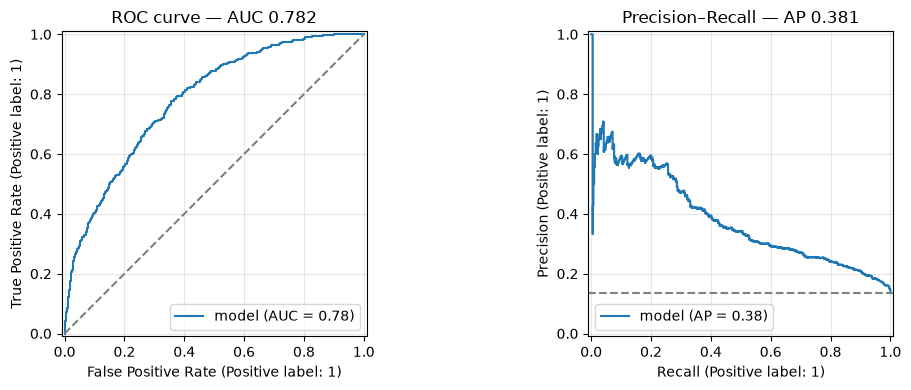

In [5]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, average_precision_score, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(actual, probabilities, ax=axes[0], name="model")
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set_title(f"ROC curve — AUC {roc_auc_score(actual, probabilities):.3f}")

PrecisionRecallDisplay.from_predictions(actual, probabilities, ax=axes[1], name="model")
axes[1].axhline(actual.mean(), linestyle="--", color="grey")
axes[1].set_title(f"Precision–Recall — AP {average_precision_score(actual, probabilities):.3f}")
plt.tight_layout()
plt.show()

AUC 0.782 against a 0.5 baseline sounds respectable. Average precision 0.381
against a 0.135 baseline tells a sharper story: at any recall you choose, most of
what you flag is still a good customer.

| Use | When |
|-----|------|
| **ROC-AUC** | Roughly balanced classes; you care about ranking overall; comparing models |
| **PR-AUC** | Rare positives; you care about what happens among the cases you flag |

With 13.5% positives, PR-AUC is the more honest summary — ROC curves look
flattering on imbalanced data because true negatives are abundant and easy.

Both are still only **summaries of the ranking**. Neither tells you where to cut,
and neither knows that a missed default costs twelve times a false alarm. For
that we need money.

---

## 4. The cost matrix — how the metric is actually chosen

A metric is a proxy. Money is the thing. If you can put a number on each cell of
the confusion matrix, you can stop arguing about metrics and compute the answer.

| | Model says repay | Model says default |
|---|---|---|
| **Actually repaid** | 0 — business as usual | Lost interest margin: **4.5%** of the loan |
| **Actually defaulted** | Loss after recovery: **55%** of the loan | 0 — we avoided it |

Those two percentages come from the credit team, not from you. Getting them
written down is the single highest-value conversation in the project.

In [6]:
LOSS_GIVEN_DEFAULT = 0.55    # of the loan amount, when a default is missed
FORGONE_MARGIN = 0.045       # of the loan amount, when a good loan is declined

costs = []
for threshold in sweep.index:
    predictions = (probabilities >= threshold).astype(int)
    missed = loan_amounts[(actual == 1) & (predictions == 0)].sum() * LOSS_GIVEN_DEFAULT
    false_alarms = loan_amounts[(actual == 0) & (predictions == 1)].sum() * FORGONE_MARGIN
    costs.append((missed + false_alarms) / 1e6)

sweep["cost_NPR_m"] = np.round(costs, 1)
print(sweep[["recall", "precision", "f1", "accuracy", "flagged", "cost_NPR_m"]].to_string())

cheapest = sweep["cost_NPR_m"].idxmin()
print(f"\ncheapest threshold: {cheapest}  (NPR {sweep.loc[cheapest, 'cost_NPR_m']:.1f}m)")
print(f"best-F1 threshold:  {sweep['f1'].idxmax()}  (NPR {sweep.loc[sweep['f1'].idxmax(), 'cost_NPR_m']:.1f}m)")
print(f"best-accuracy:      {sweep['accuracy'].idxmax()}  (NPR {sweep.loc[sweep['accuracy'].idxmax(), 'cost_NPR_m']:.1f}m)")

           recall  precision     f1  accuracy  flagged  cost_NPR_m
threshold                                                         
0.05        0.968      0.174  0.295     0.374    0.752        36.9
0.10        0.817      0.237  0.368     0.620    0.465        36.0
0.15        0.644      0.284  0.394     0.732    0.307        44.0
0.20        0.511      0.333  0.403     0.796    0.207        55.0
0.25        0.407      0.382  0.394     0.831    0.144        62.9
0.30        0.328      0.442  0.377     0.853    0.100        69.8
0.35        0.274      0.519  0.359     0.868    0.071        75.1
0.40        0.217      0.553  0.312     0.871    0.053        81.5
0.45        0.165      0.593  0.259     0.872    0.038        85.6
0.50        0.091      0.569  0.157     0.868    0.022        92.4

cheapest threshold: 0.1  (NPR 36.0m)
best-F1 threshold:  0.2  (NPR 55.0m)
best-accuracy:      0.45  (NPR 85.6m)


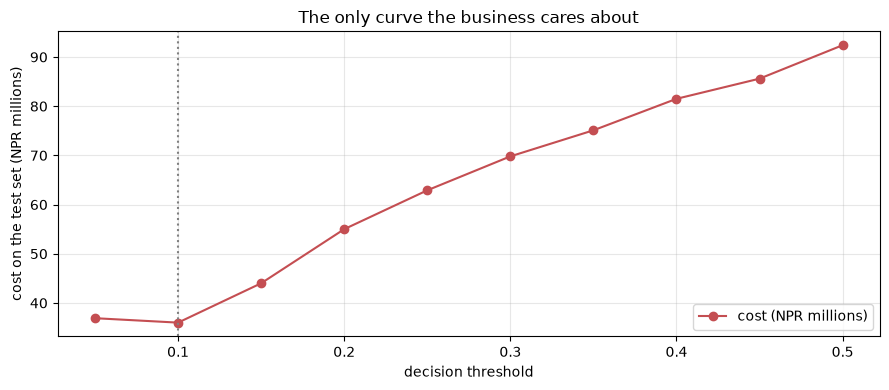

In [7]:
fig, ax = plt.subplots()
ax.plot(sweep.index, sweep["cost_NPR_m"], marker="o", color="#C44E52", label="cost (NPR millions)")
ax.axvline(cheapest, linestyle=":", color="grey")
ax.set_xlabel("decision threshold")
ax.set_ylabel("cost on the test set (NPR millions)")
ax.set_title("The only curve the business cares about")
ax.legend()
plt.tight_layout()
plt.show()

Read those three lines again, because they are the point of the session.

- Optimising **accuracy** picks 0.45 and costs **NPR 85.6m**.
- Optimising **F1** picks 0.20 and costs **NPR 55.0m**.
- Optimising **money** picks 0.10 and costs **NPR 36.0m**.

Choosing F1 over expected cost — a completely standard, defensible-sounding
choice — burns about **19 million rupees per quarter** on this test set. No
modelling change could recover that. The metric did it.

Two things to notice about the cost curve itself.

**It is flat near the bottom.** Thresholds 0.05 and 0.10 cost 36.9m and 36.0m.
The exact number matters far less than the region, which is a relief: you do not
need a precise estimate of the cost ratio, only a roughly right one.

**It rises steeply on the right.** Being too cautious is cheap to say and
expensive to do, because the missed defaults dominate everything.

> **Industry note — where the cost numbers come from.**
> Teams stall for weeks waiting for perfect cost figures. You do not need them.
> Ask the credit team for a range, take the midpoint, and show them this curve.
> Disagreement about whether the ratio is 10:1 or 15:1 barely moves the chosen
> threshold; disagreement about whether it is 1:1 or 12:1 changes the entire
> product. Argue about the order of magnitude, then move on.

---

## 5. Capacity: the constraint the cost curve ignores

The cheapest threshold, 0.10, flags **46.5%** of applications for review. Session
1's charter said no more than 25%, because twelve files per branch per month is
what the credit team can actually read.

The cost curve does not know that. It assumes every flagged file gets reviewed
perfectly and for free.

In [8]:
CAPACITY = 0.25     # the charter's guardrail: at most 25% of applications reviewed

affordable = sweep[sweep["flagged"] <= CAPACITY]
best_affordable = affordable["cost_NPR_m"].idxmin()

print(f"unconstrained best: threshold {cheapest}  "
      f"recall {sweep.loc[cheapest, 'recall']:.2f}  flagged {sweep.loc[cheapest, 'flagged']:.0%}  "
      f"NPR {sweep.loc[cheapest, 'cost_NPR_m']:.1f}m")
print(f"within capacity:    threshold {best_affordable}  "
      f"recall {sweep.loc[best_affordable, 'recall']:.2f}  flagged {sweep.loc[best_affordable, 'flagged']:.0%}  "
      f"NPR {sweep.loc[best_affordable, 'cost_NPR_m']:.1f}m")
print(f"\nthe capacity limit costs NPR "
      f"{sweep.loc[best_affordable, 'cost_NPR_m'] - sweep.loc[cheapest, 'cost_NPR_m']:.1f}m")

unconstrained best: threshold 0.1  recall 0.82  flagged 46%  NPR 36.0m
within capacity:    threshold 0.2  recall 0.51  flagged 21%  NPR 55.0m

the capacity limit costs NPR 19.0m


That last number is the most useful sentence you can hand a Head of Credit:
*"reviewing only a quarter of applications instead of nearly half costs about 19
million rupees a quarter — here is what hiring two more credit officers would be
worth."*

That is not a modelling result. It is a business case, and it came from a metric
table.

Also notice: session 1's criterion (recall ≥ 0.60 at ≤ 25% flagged) is still not
met — the best operating point inside the capacity limit reaches recall 0.51. The charter's target was written
before anyone had seen a model. Sessions 6 and 7 try to close the gap; if they
cannot, the honest move is to renegotiate the charter, not to quietly change the
metric.

---

## 6. Calibration: do the probabilities mean anything?

Everything in section 4 multiplied a probability by money. That only works if the
probabilities are **calibrated** — when the model says 20%, roughly 20% of those
applicants should actually default.

Ranking and calibration are different properties. A model can rank perfectly and
still be badly calibrated.

In [9]:
buckets = pd.cut(probabilities, [0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0])

calibration = pd.DataFrame({"predicted": probabilities, "actual": actual, "bucket": buckets})
calibration = calibration.groupby("bucket", observed=True).agg(
    applications=("actual", "size"),
    mean_predicted=("predicted", "mean"),
    actual_rate=("actual", "mean"),
).round(3)
print(calibration.to_string())

             applications  mean_predicted  actual_rate
bucket                                                
(0.0, 0.05]           744           0.032        0.017
(0.05, 0.1]           860           0.073        0.071
(0.1, 0.2]            774           0.142        0.160
(0.2, 0.3]            321           0.244        0.231
(0.3, 0.5]            236           0.385        0.407
(0.5, 1.0]             65           0.613        0.569


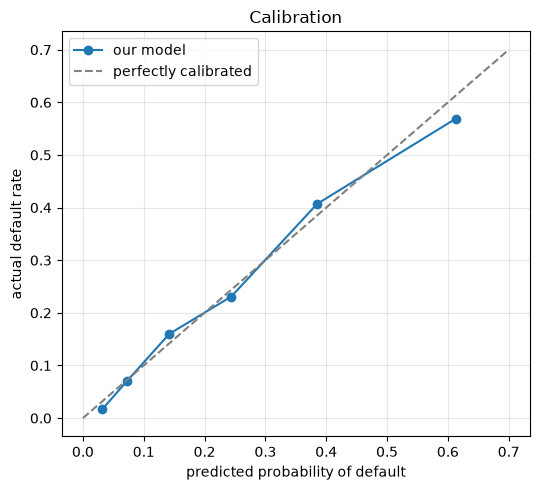

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(calibration["mean_predicted"], calibration["actual_rate"], marker="o", label="our model")
ax.plot([0, 0.7], [0, 0.7], "--", color="grey", label="perfectly calibrated")
ax.set_xlabel("predicted probability of default")
ax.set_ylabel("actual default rate")
ax.set_title("Calibration")
ax.legend()
plt.tight_layout()
plt.show()

Close to the diagonal in every bucket — this model's probabilities can be trusted
as probabilities, which is why the cost arithmetic in section 4 is meaningful.

Logistic regression is usually well calibrated because its training objective is
a probability loss. Tree ensembles often are not: random forests tend to avoid
the extremes, and boosted models push toward them. If you swap in one of those
and keep the cost calculation, check this plot first, and use
`CalibratedClassifierCV` if the curve bends away from the diagonal.

---

## 7. Regression metrics, briefly

For the pricing question from session 4 — predicting the interest rate — the
same discipline applies with different arithmetic.

| Metric | What it says | Use when |
|--------|--------------|----------|
| **MAE** | Average error, in the target's own units | You want a number stakeholders can feel |
| **RMSE** | Like MAE but punishes large errors harder | Big misses are disproportionately costly |
| **R²** | Share of variance explained, 0 to 1 | Comparing models on the same target |
| **MAPE** | Average error as a percentage | Scale varies wildly across rows; fails on zeros |

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rate_features = loans[["loan_amount", "tenure_months", "previous_loans",
                       "days_past_due_history", "credit_score", "annual_income"]]
rate_features = rate_features.fillna(rate_features.median())

A_train, A_test, r_train, r_test = train_test_split(
    rate_features, loans["interest_rate"], test_size=0.25, random_state=42
)
rate_model = LinearRegression().fit(A_train, r_train)
predicted_rate = rate_model.predict(A_test)

print(f"MAE  {mean_absolute_error(r_test, predicted_rate):.3f} percentage points")
print(f"RMSE {np.sqrt(mean_squared_error(r_test, predicted_rate)):.3f} percentage points")
print(f"R²   {r2_score(r_test, predicted_rate):.3f}")

MAE  0.778 percentage points
RMSE 0.973 percentage points
R²   0.565


RMSE above MAE is normal and the gap is the signal: it says a minority of
applications are priced far from what the model expects. For a pricing-consistency
review, those outliers are the whole point — so here you would report RMSE *and*
go look at the worst rows.

---

## 8. What to report, and to whom

| Audience | Give them | Not |
|----------|-----------|-----|
| Head of Credit | Expected cost, recall at the agreed capacity, in rupees and files | AUC |
| Credit officers | What lands in their queue each day, and how often it is worth reading | Anything with "curve" in the name |
| Risk / compliance | Operating point, calibration, slice performance, guardrails | A single headline number |
| Your team | AUC or PR-AUC for model comparison, plus the cost curve | Accuracy |

**One number for the business, several for the team.** The business number is the
one from the charter — here, cost in rupees at the capacity limit. The team's
numbers exist to make that one number move.

Report the operating point together with the metric, always. "Recall 0.64" is
meaningless; "recall 0.64 while flagging 31% of applications, at threshold 0.15"
is a result someone can act on and reproduce.

---

## Your turn

**1. Move the cost ratio.** Re-run section 4 with `LOSS_GIVEN_DEFAULT = 0.30`
and again with `0.80`. How far does the cheapest threshold move? Does your answer
change what you would tell the credit team to spend time agreeing on?

**2. Cost per application.** Our cost is a total over 3,000 test applications.
Divide by the number of applications to get cost per file, at the cheapest
threshold and at the accuracy-optimal one. Which number is more persuasive in a
meeting, and why?

**3. Add a review cost.** Reviewing a flagged file takes an officer 30 minutes,
at NPR 400 an hour. Add that to the cost function for every flagged application
and re-find the cheapest threshold. Does the capacity constraint still bind?

**4. Break calibration.** Train a `RandomForestClassifier`, plot its calibration
curve next to the logistic model's, and redo the cost table with its
probabilities. Does the cheapest threshold move? What would go wrong if you used
uncalibrated probabilities in a pricing decision?

**5. Slice it.** Compute recall and flag rate separately for `sector == "Tourism"`
and `sector == "Trade"` at threshold 0.15. Is the model equally useful for both?
(This is the opening move of session 6.)

**6. Rewrite the charter line.** Session 1 asked for recall ≥ 0.60 at ≤ 25%
flagged, which we cannot reach. Write the replacement criterion you would take
back to the Head of Credit, in one sentence, with the evidence from this notebook
behind it.

---

## If you remember nothing else

**Four counts underpin everything.** Caught defaults, missed defaults, false
alarms, quiet approvals. Every classification metric is a ratio of those.

**Accuracy is irrelevant on imbalanced problems.** It peaked here at a threshold
that misses five defaults out of six.

**ROC-AUC flatters imbalanced data.** With rare positives, precision–recall tells
you more, and its baseline is the base rate, not 0.5.

**Cost beats every metric.** Optimising F1 instead of expected cost was worth
about NPR 19 million a quarter on this test set. Get the two cost numbers from
the business and compute the curve.

**A metric without an operating point is not a result.** Always report the
threshold and what it does to the queue.

**Calibration is what makes money arithmetic legal.** If the probabilities do not
mean what they say, multiplying them by rupees produces confident nonsense.

**Constraints outrank optima.** The cheapest threshold flagged 46% of
applications; the team can read 25%. Pricing the gap is a business case, not a
failure.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Confusion matrix** | The 2×2 table of predicted against actual classes |
| **Precision** | Of the files we flagged, the share that were really bad |
| **Recall / sensitivity** | Of the bad files, the share we caught |
| **Specificity** | Of the good files, the share we left alone |
| **F1** | Harmonic mean of precision and recall |
| **ROC-AUC** | Probability the model ranks a random positive above a random negative |
| **PR-AUC / average precision** | Area under the precision–recall curve; baseline is the base rate |
| **Base rate** | The share of positives in the data — 13.5% here |
| **Operating point** | The recall/precision pair produced by a chosen threshold |
| **Cost matrix** | The money attached to each cell of the confusion matrix |
| **Expected cost** | Total money lost at a given operating point |
| **Calibration** | Whether predicted probabilities match observed frequencies |
| **MAE / RMSE / R²** | Regression metrics: average error, outlier-sensitive error, variance explained |

## Further reading

- scikit-learn User Guide, *Metrics and scoring* — every metric in this session,
  with the formulas.
- Google, *Classification: ROC and AUC* — short, visual, and free.
- Provost and Fawcett, *Data Science for Business*, chapters 7–8 — expected value
  framing and cost matrices, written for exactly this conversation.
- Niculescu-Mizil and Caruana, *Predicting Good Probabilities with Supervised
  Learning* (ICML 2005) — why forests and boosted trees need calibrating.

---

**Next session:** *Model Tuning and Error Analysis* — cross-validation done
correctly, hyperparameter search, learning curves, and finding the slices of the
book where this model quietly fails.